# Policy Exception Tracking & Complaint Governance Dashboard
## Business Scenario

### You are acting as a GRC Analyst / Compliance Analyst / Operational Risk Analyst for a financial institution.

#### Leadership wants to monitor complaint-related policy exceptions, including:

- untimely responses
- missing company responses
- unresolved or concerning complaint outcomes
- missing complaint documentation
- disputed complaints
- high-risk products
- repeat issue categories
- state-level exception concentrations
- overdue remediation
- policy control failures

---

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile

plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv(r"C:\Users\Amira\Downloads\Project6_policy_exception\complaints-2026-05-11_20_14.csv")

print(df.shape)
df.head()

(4068743, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,04/24/26,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was result of identity theft,NaN,NaN,AMERICAN EXPRESS COMPANY,MI,482XX,NaN,NaN,Web,04/24/26,In progress,Yes,NaN,21573846.0
1,07/11/25,Debt collection,I do not know,Electronic communications,Frequent or repeated messages,NaN,NaN,"Shepherd Outsourcing, LLC",SC,29150,NaN,Consent not provided,Web,07/11/25,Closed with explanation,Yes,NaN,14586539.0
2,05/02/26,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,GA,31721,NaN,NaN,Web,05/02/26,In progress,Yes,NaN,21813467.0
3,09/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,30281,Older American,Consent not provided,Web,09/01/25,Closed with non-monetary relief,Yes,NaN,15652027.0
4,05/01/26,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,10453,NaN,NaN,Web,05/01/26,Closed with explanation,Yes,NaN,21805777.0


In [91]:
#clean columns names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("?", "", regex=False)
)

df = df.rename(columns={
    "sub-product": "sub_product",
    "sub-issue": "sub_issue"
})

df.columns.tolist()

['date_received',
 'product',
 'sub_product',
 'issue',
 'sub_issue',
 'consumer_complaint_narrative',
 'company_public_response',
 'company',
 'state',
 'zip_code',
 'tags',
 'consumer_consent_provided',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'consumer_disputed',
 'complaint_id']

In [92]:
#convert dates
df["date_received"] = pd.to_datetime(
    df["date_received"],
    errors="coerce"
)

df["date_sent_to_company"] = pd.to_datetime(
    df["date_sent_to_company"],
    errors="coerce"
)

C:\Users\Amira\AppData\Local\Temp\ipykernel_33592\1094164562.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_received"] = pd.to_datetime(
C:\Users\Amira\AppData\Local\Temp\ipykernel_33592\1094164562.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_sent_to_company"] = pd.to_datetime(


In [93]:
#response delay
df["days_to_send"] = (
    df["date_sent_to_company"] - df["date_received"]
).dt.days

df[[
    "date_received",
    "date_sent_to_company",
    "days_to_send"
]].head()

,date_received,date_sent_to_company,days_to_send
0,2026-04-24,2026-04-24,0.0
1,2025-07-11,2025-07-11,0.0
2,2026-05-02,2026-05-02,0.0
3,2025-09-01,2025-09-01,0.0
4,2026-05-01,2026-05-01,0.0


In [94]:
#missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    (missing / len(df)) * 100
).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
})

missing_df

,Missing Count,Missing Percent
consumer_disputed,4068743,100.00
tags,3979783,97.81
consumer_complaint_narrative,3560469,87.51
company_public_response,1911508,46.98
consumer_consent_provided,1009657,24.81
sub_issue,48029,1.18
state,5033,0.12
zip_code,24,0.00
company_response_to_consumer,1,0.00
date_sent_to_company,1,0.00


In [95]:
#overview
print("Total Complaints:", len(df))
print("Unique Companies:", df["company"].nunique())
print("Unique Products:", df["product"].nunique())
print("Unique Issues:", df["issue"].nunique())
print("Unique States:", df["state"].nunique())

Total Complaints: 4068743
Unique Companies: 3540
Unique Products: 11
Unique Issues: 90
Unique States: 61


In [96]:
##Policy exception flags

#untimely response flag
df["untimely_response_exception"] = (
    df["timely_response"].str.lower() == "no"
)

df["untimely_response_exception"].sum()

#missing company
df["missing_company_response_exception"] = (
    df["company_response_to_consumer"].isna()
)

df["missing_company_response_exception"].sum()

#missing narative/documentation
df["missing_narrative_exception"] = (
    df["consumer_complaint_narrative"].isna()
)

df["missing_narrative_exception"].sum()

#missing state
df["missing_state_exception"] = (
    df["state"].isna()
)

df["missing_state_exception"].sum()

#disputed
df["consumer_disputed_exception"] = (
    df["consumer_disputed"]
    .astype("string")
    .str.lower()
    .eq("yes")
)

df["consumer_disputed_exception"].sum()

np.int64(0)

In [97]:
#delayed company send (3 days)
df["delayed_send_exception"] = (
    df["days_to_send"] > 3
)

df["delayed_send_exception"].sum()

#duplicates
df["duplicate_complaint_exception"] = (
    df.duplicated(subset="complaint_id")
)

df["duplicate_complaint_exception"].sum()

np.int64(0)

In [98]:
# Make sure exception columns are spelled correctly
exception_cols = [
    "untimely_response_exception",
    "missing_company_response_exception",
    "consumer_disputed_exception",
    "missing_narrative_exception",
    "missing_state_exception",
    "delayed_send_exception",
    "duplicate_complaint_exception"
]

# Clean all exception flags to True/False
for col in exception_cols:
    df[col] = df[col].fillna(False).astype(bool)

# Create policy exception score
df["policy_exception_score"] = (
    df[exception_cols]
    .sum(axis=1)
)

# Create policy exception level
df["policy_exception_level"] = np.select(
    [
        df["policy_exception_score"] == 0,
        df["policy_exception_score"] == 1,
        df["policy_exception_score"] == 2,
        df["policy_exception_score"] == 3,
        df["policy_exception_score"] >= 4
    ],
    [
        "None",
        "Low",
        "Medium",
        "High",
        "Critical"
    ],
    default="None"
)

df[exception_cols + ["policy_exception_score", "policy_exception_level"]].head()

,untimely_response_exception,missing_company_response_exception,consumer_disputed_exception,missing_narrative_exception,missing_state_exception,delayed_send_exception,duplicate_complaint_exception,policy_exception_score,policy_exception_level
0,False,False,False,True,False,False,False,1,Low
1,False,False,False,True,False,False,False,1,Low
2,False,False,False,True,False,False,False,1,Low
3,False,False,False,True,False,False,False,1,Low
4,False,False,False,True,False,False,False,1,Low


In [99]:
#policy exception severity
def policy_exception_level(score):

    if score == 0:
        return "None"

    elif score == 1:
        return "Low"

    elif score == 2:
        return "Medium"

    elif score == 3:
        return "High"

    else:
        return "Critical"


df["policy_exception_level"] = (
    df["policy_exception_score"]
    .apply(policy_exception_level)
)

In [100]:
#review
df[[
    "complaint_id",
    "product",
    "issue",
    "company",
    "timely_response",
    "company_response_to_consumer",
    "consumer_disputed",
    "days_to_send",
    "policy_exception_score",
    "policy_exception_level"
]].head(10)

,complaint_id,product,issue,company,timely_response,company_response_to_consumer,consumer_disputed,days_to_send,policy_exception_score,policy_exception_level
0,21573846.0,Debt collection,Attempts to collect debt not owed,AMERICAN EXPRESS COMPANY,Yes,In progress,NaN,0.0,1,Low
1,14586539.0,Debt collection,Electronic communications,"Shepherd Outsourcing, LLC",Yes,Closed with explanation,NaN,0.0,1,Low
2,21813467.0,Credit reporting or other personal consumer re...,Incorrect information on your report,Experian Information Solutions Inc.,Yes,In progress,NaN,0.0,1,Low
3,15652027.0,Credit reporting or other personal consumer re...,Incorrect information on your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Yes,Closed with non-monetary relief,NaN,0.0,1,Low
4,21805777.0,Credit reporting or other personal consumer re...,Improper use of your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Yes,Closed with explanation,NaN,0.0,1,Low
5,16316337.0,Credit reporting or other personal consumer re...,Incorrect information on your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Yes,Closed with explanation,NaN,0.0,0,None
6,14573091.0,Credit reporting or other personal consumer re...,Incorrect information on your report,World Omni Financial Corp.,Yes,Closed with explanation,NaN,0.0,2,Medium
7,21806280.0,Credit reporting or other personal consumer re...,Improper use of your report,Experian Information Solutions Inc.,Yes,In progress,NaN,0.0,1,Low
8,21804351.0,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,"EQUIFAX, INC.",Yes,Closed with explanation,NaN,0.0,1,Low
9,19356680.0,Debt collection,Written notification about debt,"Portfolio Recovery Associates, LLC",Yes,Closed with non-monetary relief,NaN,0.0,1,Low


In [101]:
#auto policy control testing

#rules
df["ctrl_complaint_id_present"] = df["complaint_id"].notna()

df["ctrl_product_present"] = df["product"].notna()

df["ctrl_company_present"] = df["company"].notna()

df["ctrl_response_present"] = df["company_response_to_consumer"].notna()

df["ctrl_timely_response"] = (
    df["timely_response"].str.lower() == "yes"
)

df["ctrl_state_present"] = df["state"].notna()

df["ctrl_no_duplicate_complaint"] = (
    ~df["duplicate_complaint_exception"]
)

#summary
control_tests = {
    "CTRL-001 Complaint ID Present": "ctrl_complaint_id_present",
    "CTRL-002 Product Present": "ctrl_product_present",
    "CTRL-003 Company Present": "ctrl_company_present",
    "CTRL-004 Company Response Present": "ctrl_response_present",
    "CTRL-005 Timely Response": "ctrl_timely_response",
    "CTRL-006 State Present": "ctrl_state_present",
    "CTRL-007 No Duplicate Complaint ID": "ctrl_no_duplicate_complaint"
}

control_results = []

for control_name, rule_col in control_tests.items():

    total_tested = len(df)
    passed = int(df[rule_col].sum())
    failed = total_tested - passed
    pass_rate = round((passed / total_tested) * 100, 2)

    if pass_rate >= 95:
        effectiveness = "Effective"
    elif pass_rate >= 85:
        effectiveness = "Needs Monitoring"
    else:
        effectiveness = "Ineffective"

    control_results.append({
        "Control": control_name,
        "Total Tested": total_tested,
        "Passed": passed,
        "Failed": failed,
        "Pass Rate %": pass_rate,
        "Effectiveness": effectiveness
    })

control_summary_df = pd.DataFrame(control_results)

control_summary_df


,Control,Total Tested,Passed,Failed,Pass Rate %,Effectiveness
0,CTRL-001 Complaint ID Present,4068743,4068742,1,100.00,Effective
1,CTRL-002 Product Present,4068743,4068743,0,100.00,Effective
2,CTRL-003 Company Present,4068743,4068742,1,100.00,Effective
3,CTRL-004 Company Response Present,4068743,4068742,1,100.00,Effective
4,CTRL-005 Timely Response,4068743,4052304,16439,99.60,Effective
5,CTRL-006 State Present,4068743,4063710,5033,99.88,Effective
6,CTRL-007 No Duplicate Complaint ID,4068743,4068743,0,100.00,Effective


In [102]:
#exception register
policy_exception_register = df[
    df["policy_exception_score"] > 0
].copy()

policy_exception_register = policy_exception_register[[
    "complaint_id",
    "date_received",
    "date_sent_to_company",
    "days_to_send",
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company",
    "state",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response",
    "consumer_disputed",
    "policy_exception_score",
    "policy_exception_level",
    "untimely_response_exception",
    "missing_company_response_exception",
    "consumer_disputed_exception",
    "missing_narrative_exception",
    "missing_state_exception",
    "delayed_send_exception",
    "duplicate_complaint_exception"
]]

policy_exception_register.head()

,complaint_id,date_received,date_sent_to_company,days_to_send,product,sub_product,issue,sub_issue,company,state,...,consumer_disputed,policy_exception_score,policy_exception_level,untimely_response_exception,missing_company_response_exception,consumer_disputed_exception,missing_narrative_exception,missing_state_exception,delayed_send_exception,duplicate_complaint_exception
0,21573846.0,2026-04-24,2026-04-24,0.0,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was result of identity theft,AMERICAN EXPRESS COMPANY,MI,...,NaN,1,Low,False,False,False,True,False,False,False
1,14586539.0,2025-07-11,2025-07-11,0.0,Debt collection,I do not know,Electronic communications,Frequent or repeated messages,"Shepherd Outsourcing, LLC",SC,...,NaN,1,Low,False,False,False,True,False,False,False
2,21813467.0,2026-05-02,2026-05-02,0.0,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Experian Information Solutions Inc.,GA,...,NaN,1,Low,False,False,False,True,False,False,False
3,15652027.0,2025-09-01,2025-09-01,0.0,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,...,NaN,1,Low,False,False,False,True,False,False,False
4,21805777.0,2026-05-01,2026-05-01,0.0,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,...,NaN,1,Low,False,False,False,True,False,False,False


In [103]:
#save
Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

policy_exception_register.to_csv(
    "outputs/tables/policy_exception_register.csv",
    index=False
)

print("Policy exception register saved successfully.")

Policy exception register saved successfully.


In [104]:
##======KPIs======##

#kpi calcs
total_complaints = len(df)

total_exceptions = len(policy_exception_register)

exception_rate = round(
    (total_exceptions / total_complaints) * 100,
    2
)

high_exceptions = len(
    df[df["policy_exception_level"] == "High"]
)

critical_exceptions = len(
    df[df["policy_exception_level"] == "Critical"]
)

untimely_responses = int(
    df["untimely_response_exception"].sum()
)

disputed_complaints = int(
    df["consumer_disputed_exception"].sum()
)

delayed_sends = int(
    df["delayed_send_exception"].sum()
)

print("Total Complaints:", total_complaints)
print("Total Exceptions:", total_exceptions)
print("Exception Rate:", exception_rate)
print("High Exceptions:", high_exceptions)
print("Critical Exceptions:", critical_exceptions)
print("Untimely Responses:", untimely_responses)
print("Disputed Complaints:", disputed_complaints)
print("Delayed Sends:", delayed_sends)

Total Complaints: 4068743
Total Exceptions: 3578744
Exception Rate: 87.96
High Exceptions: 1452
Critical Exceptions: 7
Untimely Responses: 16438
Disputed Complaints: 0
Delayed Sends: 48300


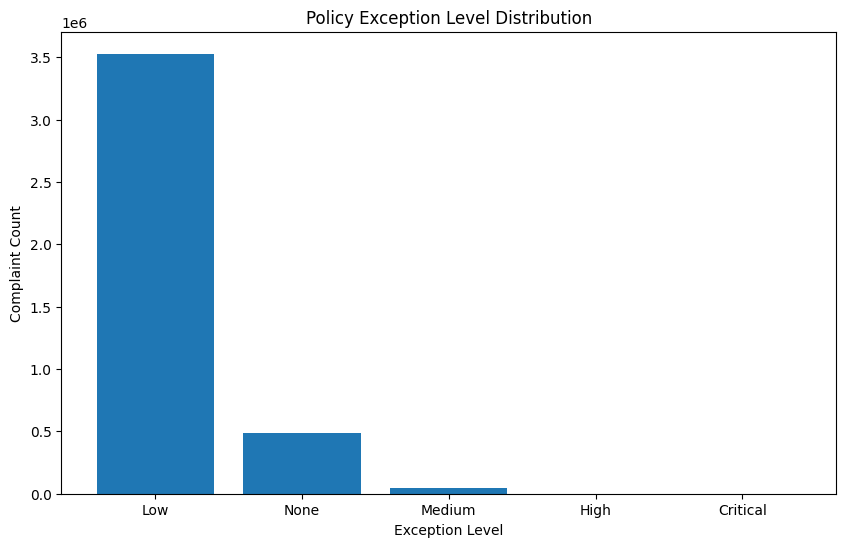

In [105]:
#exception level dist
exception_level_counts = (
    df["policy_exception_level"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    exception_level_counts.index,
    exception_level_counts.values
)

plt.title("Policy Exception Level Distribution")
plt.xlabel("Exception Level")
plt.ylabel("Complaint Count")

plt.show()

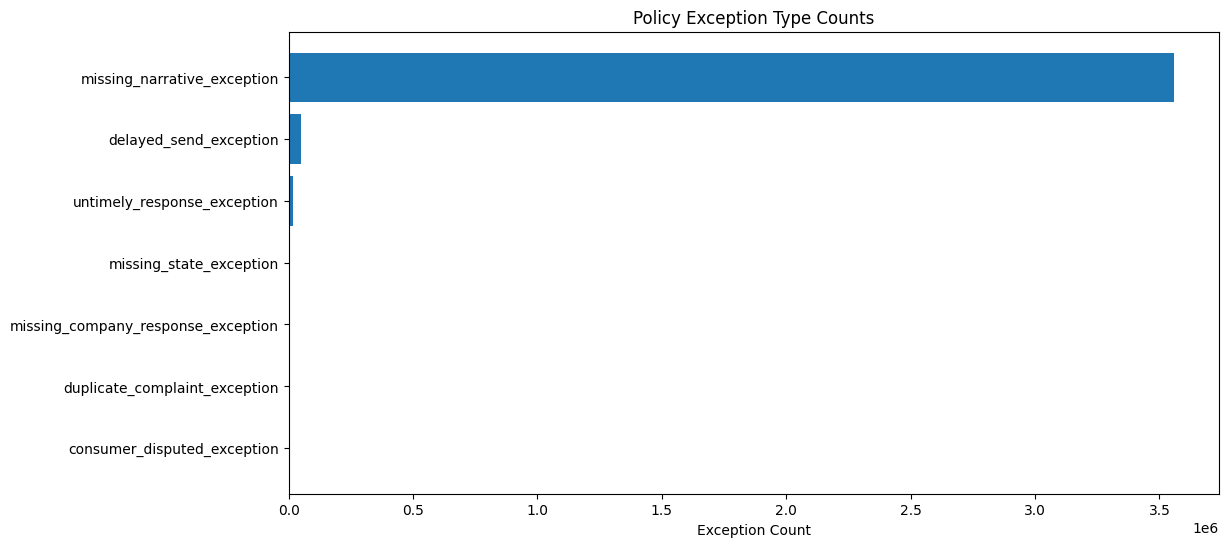

In [106]:
#type counts
exception_type_counts = (
    df[exception_cols]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    exception_type_counts.index,
    exception_type_counts.values
)

plt.title("Policy Exception Type Counts")
plt.xlabel("Exception Count")

plt.show()

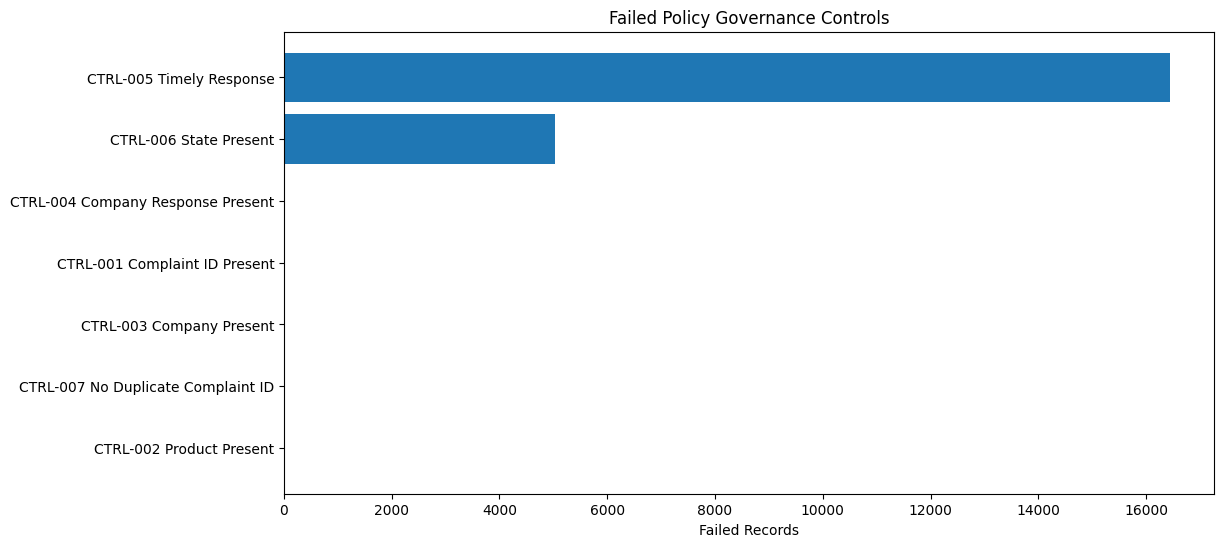

In [107]:
#failed policy controls
failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    failed_control_chart["Control"],
    failed_control_chart["Failed"]
)

plt.title("Failed Policy Governance Controls")
plt.xlabel("Failed Records")

plt.show()

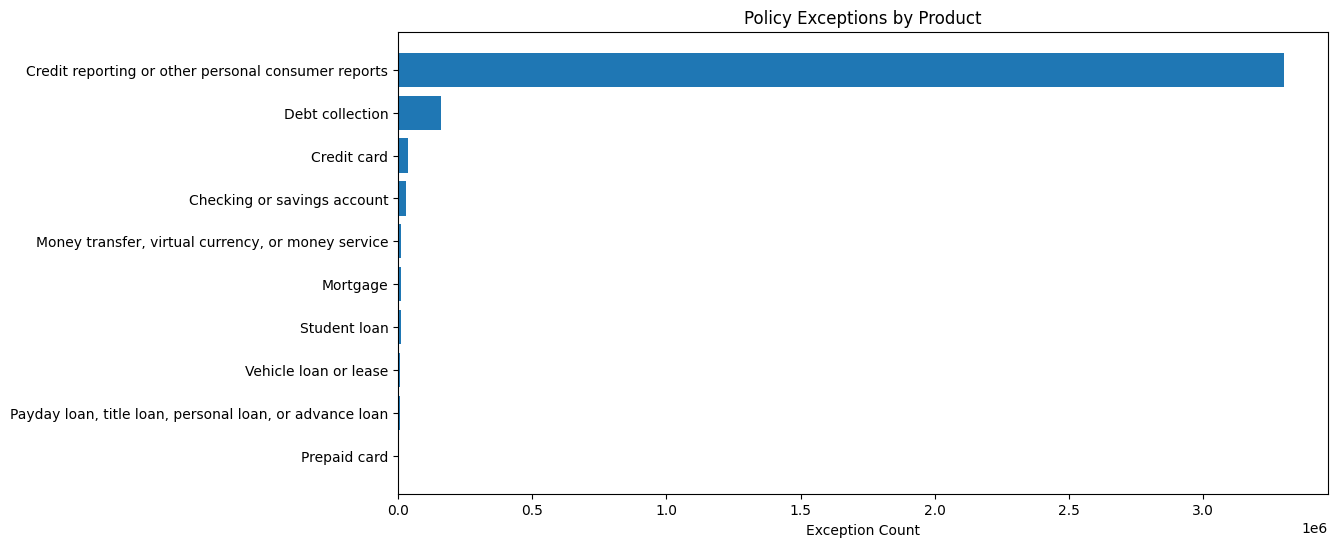

In [108]:
#exceptions by product
exceptions_by_product = (
    policy_exception_register
    .groupby("product")
    .size()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    exceptions_by_product.index,
    exceptions_by_product.values
)

plt.title("Policy Exceptions by Product")
plt.xlabel("Exception Count")

plt.show()

## Policy Exception Tracking Framework

This project evaluates consumer complaint records from a policy exception and governance monitoring perspective.

The analysis creates exception flags for untimely responses, missing company responses, disputed complaints, missing complaint narratives, missing state data, delayed company notification, and duplicate complaint IDs.

Each complaint is assigned a policy exception score and classified into an exception severity level. Complaints with one or more exceptions are routed into a policy exception register for review.

The framework also includes automated control testing to evaluate complaint governance controls such as complaint ID completeness, product completeness, company completeness, response documentation, timely response performance, state completeness, and duplicate complaint prevention.

The purpose of this framework is to simulate an enterprise issue management and policy exception tracking process used by governance, compliance, operational risk, and audit teams.

---

In [109]:
##Policy exception remediation tracker

#assign owner
def assign_exception_owner(row):

    if row["untimely_response_exception"]:
        return "Complaint Response Management"

    elif row["missing_company_response_exception"]:
        return "Consumer Compliance Team"

    elif row["consumer_disputed_exception"]:
        return "Dispute Resolution Team"

    elif row["missing_narrative_exception"]:
        return "Complaint Documentation Team"

    elif row["missing_state_exception"]:
        return "Data Governance Team"

    elif row["delayed_send_exception"]:
        return "Complaint Operations"

    elif row["duplicate_complaint_exception"]:
        return "Governance Data Quality Team"

    else:
        return "Standard Monitoring"


df["exception_owner"] = df.apply(assign_exception_owner, axis=1)

#exception status
def assign_exception_status(level):

    if level == "Critical":
        return "Escalated"

    elif level == "High":
        return "Remediation Required"

    elif level == "Medium":
        return "Under Review"

    elif level == "Low":
        return "Monitoring"

    else:
        return "No Exception"


df["exception_status"] = (
    df["policy_exception_level"]
    .apply(assign_exception_status)
)

#remediation priority
def assign_remediation_priority(row):

    if row["policy_exception_level"] == "Critical":
        return "Critical"

    elif row["untimely_response_exception"]:
        return "High"

    elif row["missing_company_response_exception"]:
        return "High"

    elif row["duplicate_complaint_exception"]:
        return "High"

    elif row["consumer_disputed_exception"]:
        return "Medium"

    elif row["delayed_send_exception"]:
        return "Medium"

    elif row["missing_state_exception"]:
        return "Medium"

    elif row["missing_narrative_exception"]:
        return "Low"

    else:
        return "None"


df["remediation_priority"] = df.apply(assign_remediation_priority, axis=1)

#assign action
def assign_remediation_action(row):

    if row["policy_exception_level"] == "Critical":
        return "Immediate escalation to compliance leadership and corrective action plan required"

    elif row["untimely_response_exception"]:
        return "Review response workflow and implement SLA escalation monitoring"

    elif row["missing_company_response_exception"]:
        return "Update complaint record with complete company response documentation"

    elif row["duplicate_complaint_exception"]:
        return "Investigate duplicate complaint record and perform data quality remediation"

    elif row["consumer_disputed_exception"]:
        return "Route complaint to dispute resolution team for secondary review"

    elif row["delayed_send_exception"]:
        return "Review complaint routing delay and improve intake-to-company transfer process"

    elif row["missing_state_exception"]:
        return "Correct missing geographic data and strengthen data validation controls"

    elif row["missing_narrative_exception"]:
        return "Review documentation completeness and confirm complaint details are sufficient"

    else:
        return "No remediation required beyond standard monitoring"


df["remediation_action"] = df.apply(assign_remediation_action, axis=1)

#assign timeline
def assign_review_days(priority):

    if priority == "Critical":
        return 7

    elif priority == "High":
        return 14

    elif priority == "Medium":
        return 30

    elif priority == "Low":
        return 60

    else:
        return np.nan


df["review_days"] = np.select(
    [
        df["remediation_priority"].eq("Critical"),
        df["remediation_priority"].eq("High"),
        df["remediation_priority"].eq("Medium"),
        df["remediation_priority"].eq("Low")
    ],
    [
        7,
        14,
        30,
        60
    ],
    default=np.nan
)

#due date
df["review_due_date"] = (
    df["date_received"] +
    pd.to_timedelta(df["review_days"], unit="D")
)

#overdue flag
df["remediation_overdue_flag"] = (
    (df["policy_exception_score"] > 0) &
    (df["review_due_date"] < pd.Timestamp.today())
)





C:\Users\Amira\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arrays\timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


In [110]:
#Policy remediation register
policy_remediation_register = df[
    df["policy_exception_score"] > 0
].copy()

policy_remediation_register = policy_remediation_register[[
    "complaint_id",
    "date_received",
    "date_sent_to_company",
    "days_to_send",
    "product",
    "sub_product",
    "issue",
    "company",
    "state",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response",
    "consumer_disputed",
    "policy_exception_score",
    "policy_exception_level",
    "exception_owner",
    "exception_status",
    "remediation_priority",
    "remediation_action",
    "review_due_date",
    "remediation_overdue_flag",
    "untimely_response_exception",
    "missing_company_response_exception",
    "consumer_disputed_exception",
    "missing_narrative_exception",
    "missing_state_exception",
    "delayed_send_exception",
    "duplicate_complaint_exception"
]]

policy_remediation_register.head()

,complaint_id,date_received,date_sent_to_company,days_to_send,product,sub_product,issue,company,state,submitted_via,...,remediation_action,review_due_date,remediation_overdue_flag,untimely_response_exception,missing_company_response_exception,consumer_disputed_exception,missing_narrative_exception,missing_state_exception,delayed_send_exception,duplicate_complaint_exception
0,21573846.0,2026-04-24,2026-04-24,0.0,Debt collection,Credit card debt,Attempts to collect debt not owed,AMERICAN EXPRESS COMPANY,MI,Web,...,Review documentation completeness and confirm ...,2026-06-23,False,False,False,False,True,False,False,False
1,14586539.0,2025-07-11,2025-07-11,0.0,Debt collection,I do not know,Electronic communications,"Shepherd Outsourcing, LLC",SC,Web,...,Review documentation completeness and confirm ...,2025-09-09,True,False,False,False,True,False,False,False
2,21813467.0,2026-05-02,2026-05-02,0.0,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Experian Information Solutions Inc.,GA,Web,...,Review documentation completeness and confirm ...,2026-07-01,False,False,False,False,True,False,False,False
3,15652027.0,2025-09-01,2025-09-01,0.0,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,Web,...,Review documentation completeness and confirm ...,2025-10-31,True,False,False,False,True,False,False,False
4,21805777.0,2026-05-01,2026-05-01,0.0,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,Web,...,Review documentation completeness and confirm ...,2026-06-30,False,False,False,False,True,False,False,False


In [111]:
#save
from pathlib import Path

Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

policy_remediation_register.to_csv(
    "outputs/tables/policy_remediation_register.csv",
    index=False
)

print("Policy remediation register saved successfully.")

Policy remediation register saved successfully.


In [112]:
#high-risk exception register
high_risk_exception_register = policy_remediation_register[
    policy_remediation_register["policy_exception_level"].isin([
        "High",
        "Critical"
    ])
].copy()

high_risk_exception_register.head()

,complaint_id,date_received,date_sent_to_company,days_to_send,product,sub_product,issue,company,state,submitted_via,...,remediation_action,review_due_date,remediation_overdue_flag,untimely_response_exception,missing_company_response_exception,consumer_disputed_exception,missing_narrative_exception,missing_state_exception,delayed_send_exception,duplicate_complaint_exception
2855,16369726.0,2025-10-04,2025-10-14,10.0,Student loan,Federal student loan servicing,Struggling to repay your loan,Servicer under contract with Federal Student Aid,AZ,Web,...,Review response workflow and implement SLA esc...,2025-10-18,True,True,False,False,True,False,True,False
4212,18712465.0,2026-01-14,2026-03-03,48.0,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Credit Bureau Services Association,MS,Web,...,Review response workflow and implement SLA esc...,2026-01-28,True,True,False,False,True,False,True,False
5832,20450721.0,2026-03-20,2026-04-24,35.0,Mortgage,Conventional home mortgage,Trouble during payment process,"Mortgage Research Center, LLC",NaN,Web,...,Review complaint routing delay and improve int...,2026-04-19,True,False,False,False,True,True,True,False
7457,19506454.0,2026-02-14,2026-03-27,41.0,"Payday loan, title loan, personal loan, or adv...",Payday loan,Problem with the payoff process at the end of ...,Rosebud Economic Development Corporation,CA,Web,...,Review response workflow and implement SLA esc...,2026-02-28,True,True,False,False,True,False,True,False
9749,15775974.0,2025-09-07,2025-10-20,43.0,Debt collection,I do not know,Attempts to collect debt not owed,"Merchants & Medical Adjustment Bureau, Inc. db...",GA,Web,...,Review response workflow and implement SLA esc...,2025-09-21,True,True,False,False,True,False,True,False


In [113]:
#save
high_risk_exception_register.to_csv(
    "outputs/tables/high_risk_policy_exception_register.csv",
    index=False
)

print("High-risk policy exception register saved successfully.")

High-risk policy exception register saved successfully.


In [114]:
##======KPIs======#
total_remediation_items = len(policy_remediation_register)

overdue_remediation_items = int(
    policy_remediation_register["remediation_overdue_flag"].sum()
)

critical_priority_items = len(
    policy_remediation_register[
        policy_remediation_register["remediation_priority"] == "Critical"
    ]
)

high_priority_items = len(
    policy_remediation_register[
        policy_remediation_register["remediation_priority"] == "High"
    ]
)

escalated_items = len(
    policy_remediation_register[
        policy_remediation_register["exception_status"] == "Escalated"
    ]
)

print("Total Remediation Items:", total_remediation_items)
print("Overdue Remediation Items:", overdue_remediation_items)
print("Critical Priority Items:", critical_priority_items)
print("High Priority Items:", high_priority_items)
print("Escalated Items:", escalated_items)

Total Remediation Items: 3578744
Overdue Remediation Items: 2883773
Critical Priority Items: 7
High Priority Items: 16432
Escalated Items: 7


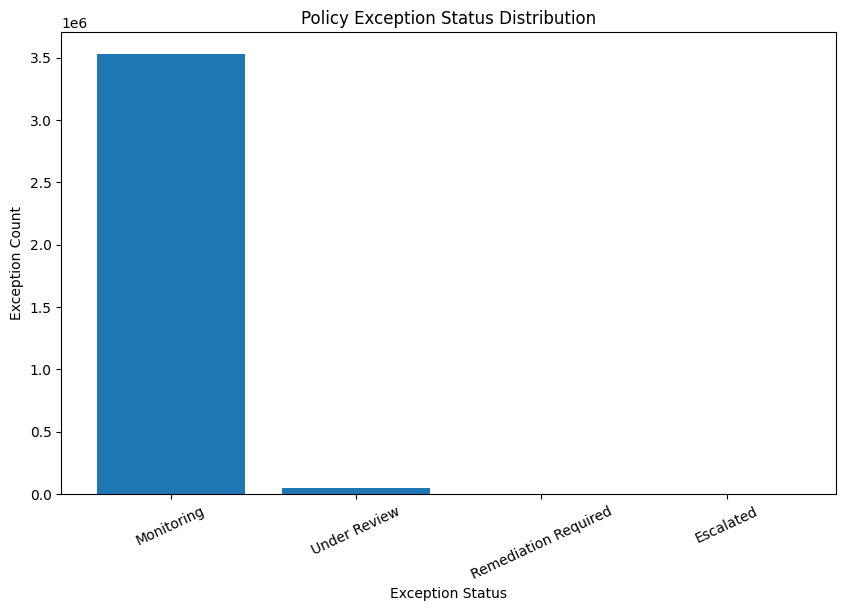

In [115]:
#exception status dist
status_counts = (
    policy_remediation_register["exception_status"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Policy Exception Status Distribution")
plt.xlabel("Exception Status")
plt.ylabel("Exception Count")

plt.xticks(rotation=25)

plt.show()

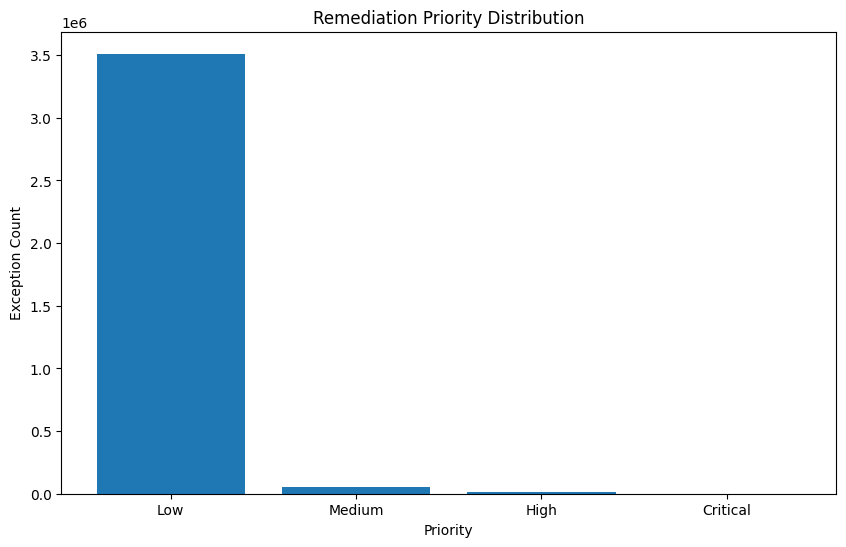

In [116]:
#remediation priority dist
priority_counts = (
    policy_remediation_register["remediation_priority"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.title("Remediation Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Exception Count")

plt.show()

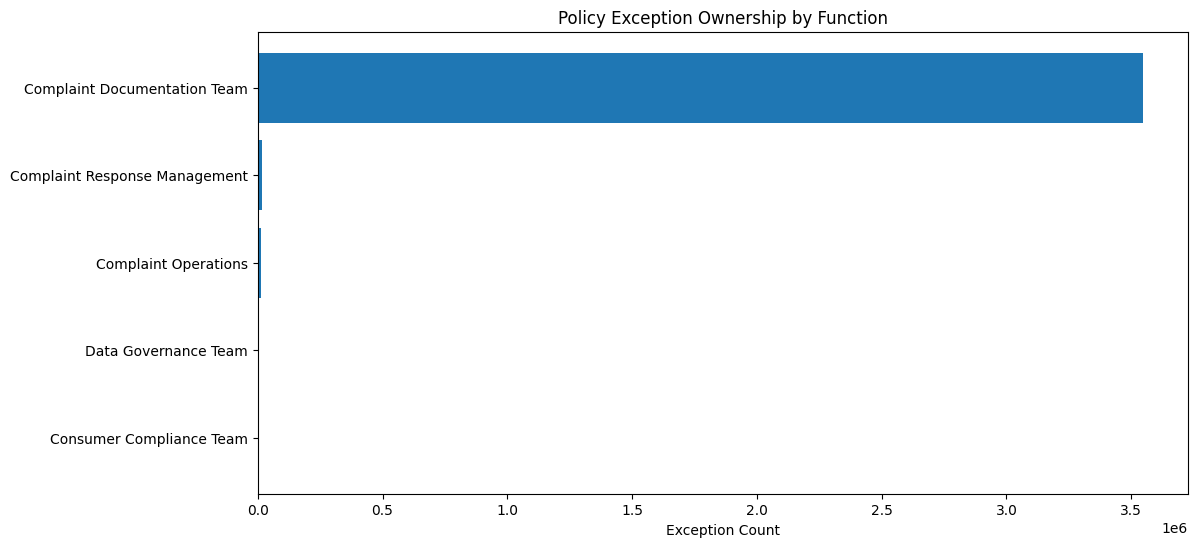

In [117]:
#owner workload
owner_counts = (
    policy_remediation_register["exception_owner"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    owner_counts.index,
    owner_counts.values
)

plt.title("Policy Exception Ownership by Function")
plt.xlabel("Exception Count")

plt.show()

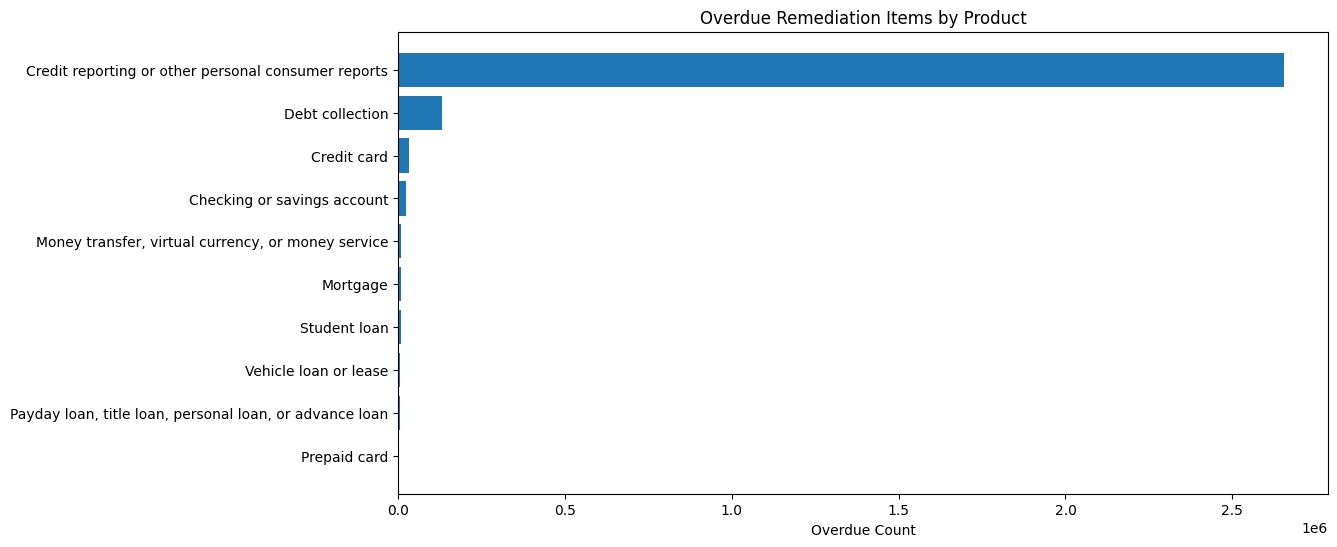

In [118]:
#overdue remediation by product
overdue_by_product = (
    policy_remediation_register[
        policy_remediation_register["remediation_overdue_flag"] == True
    ]
    .groupby("product")
    .size()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    overdue_by_product.index,
    overdue_by_product.values
)

plt.title("Overdue Remediation Items by Product")
plt.xlabel("Overdue Count")

plt.show()

## Policy Exception Remediation Tracker

A policy exception remediation tracker was created to simulate enterprise issue management and corrective action monitoring.

Each complaint with one or more policy exceptions was assigned an exception owner, exception status, remediation priority, recommended action, review due date, and overdue remediation flag.

Ownership was assigned based on the primary exception type, routing issues to functions such as Complaint Response Management, Consumer Compliance, Dispute Resolution, Data Governance, Complaint Operations, and Governance Data Quality.

Remediation timelines were assigned based on priority level. Critical items were assigned the shortest review timeline, while lower-priority exceptions were assigned longer monitoring windows.

The remediation tracker supports issue ownership, corrective action monitoring, exception prioritization, SLA escalation, audit readiness, compliance governance, and executive reporting.

---

In [119]:
##Policy exception risk matrix

#impact score
import numpy as np

df["policy_impact_score"] = np.select(
    [
        df["policy_exception_level"].eq("Critical"),
        df["policy_exception_level"].eq("High"),
        df["policy_exception_level"].eq("Medium"),
        df["policy_exception_level"].eq("Low")
    ],
    [
        4,
        3,
        2,
        1
    ],
    default=1
)

#likelihood score
df["policy_likelihood_score"] = 1

df["policy_likelihood_score"] += df["untimely_response_exception"].astype(int)
df["policy_likelihood_score"] += df["missing_company_response_exception"].astype(int)
df["policy_likelihood_score"] += df["delayed_send_exception"].astype(int)
df["policy_likelihood_score"] += df["duplicate_complaint_exception"].astype(int)

df["policy_likelihood_score"] = (
    df["policy_likelihood_score"]
    .clip(upper=4)
)

#matrix score and level
df["policy_matrix_score"] = (
    df["policy_impact_score"] *
    df["policy_likelihood_score"]
)

df["policy_matrix_level"] = np.select(
    [
        df["policy_matrix_score"] <= 3,
        df["policy_matrix_score"] <= 6,
        df["policy_matrix_score"] <= 9
    ],
    [
        "Low",
        "Medium",
        "High"
    ],
    default="Critical"
)

In [120]:
#risk matrix table
policy_risk_matrix = pd.crosstab(
    df["policy_impact_score"],
    df["policy_likelihood_score"]
)

policy_risk_matrix = policy_risk_matrix.reindex(
    index=[1, 2, 3, 4],
    columns=[1, 2, 3, 4],
    fill_value=0
)

policy_risk_matrix

policy_likelihood_score,1,2,3,4
policy_impact_score,,,,
1,4002621,16091,0,0
2,3299,44678,595,0
3,0,138,1314,0
4,0,0,7,0


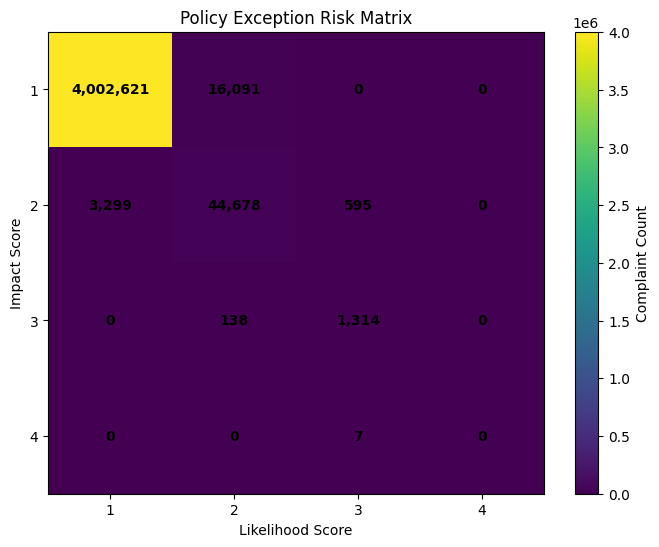

In [121]:
#heatmap
from pathlib import Path

Path("outputs/charts").mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(8, 6))

matrix_plot = plt.imshow(
    policy_risk_matrix,
    aspect="auto"
)

plt.colorbar(
    matrix_plot,
    label="Complaint Count"
)

for i in range(policy_risk_matrix.shape[0]):
    for j in range(policy_risk_matrix.shape[1]):
        value = int(policy_risk_matrix.iloc[i, j])

        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.xticks(
    ticks=range(4),
    labels=["1", "2", "3", "4"]
)

plt.yticks(
    ticks=range(4),
    labels=["1", "2", "3", "4"]
)

plt.xlabel("Likelihood Score")
plt.ylabel("Impact Score")
plt.title("Policy Exception Risk Matrix")

plt.savefig(
    "outputs/charts/policy_exception_risk_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [122]:
#critical policy exception register
critical_policy_matrix_register = df[
    df["policy_matrix_level"] == "Critical"
].copy()

critical_policy_matrix_register = critical_policy_matrix_register[[
    "complaint_id",
    "date_received",
    "product",
    "issue",
    "company",
    "state",
    "submitted_via",
    "timely_response",
    "company_response_to_consumer",
    "consumer_disputed",
    "policy_exception_score",
    "policy_exception_level",
    "policy_impact_score",
    "policy_likelihood_score",
    "policy_matrix_score",
    "policy_matrix_level",
    "exception_owner",
    "exception_status",
    "remediation_priority",
    "remediation_action",
    "review_due_date",
    "remediation_overdue_flag"
]]

critical_policy_matrix_register.head()

,complaint_id,date_received,product,issue,company,state,submitted_via,timely_response,company_response_to_consumer,consumer_disputed,...,policy_impact_score,policy_likelihood_score,policy_matrix_score,policy_matrix_level,exception_owner,exception_status,remediation_priority,remediation_action,review_due_date,remediation_overdue_flag
323729,19745195.0,2025-09-04,"Money transfer, virtual currency, or money ser...",Other service problem,"Gate US, Inc.",NaN,Web,No,Closed with explanation,NaN,...,4,3,12,Critical,Complaint Response Management,Escalated,Critical,Immediate escalation to compliance leadership ...,2025-09-11,True
1369608,15322231.0,2025-08-15,"Money transfer, virtual currency, or money ser...",Trouble accessing funds in your mobile or digi...,Abra,NaN,Web,No,Closed with explanation,NaN,...,4,3,12,Critical,Complaint Response Management,Escalated,Critical,Immediate escalation to compliance leadership ...,2025-08-22,True
2101796,14461323.0,2025-07-04,"Payday loan, title loan, personal loan, or adv...",Problem when making payments,"Hexagon Collection Services, LLC",NaN,Web,No,Untimely response,NaN,...,4,3,12,Critical,Complaint Response Management,Escalated,Critical,Immediate escalation to compliance leadership ...,2025-07-11,True
2263797,18456254.0,2026-01-04,Credit reporting or other personal consumer re...,Improper use of your report,"Tri-Emerald Financial Group, Inc.",NaN,Web,No,Untimely response,NaN,...,4,3,12,Critical,Complaint Response Management,Escalated,Critical,Immediate escalation to compliance leadership ...,2026-01-11,True
3536950,18027417.0,2025-12-14,"Money transfer, virtual currency, or money ser...",Fraud or scam,Airtm Inc.,NaN,Web,No,Untimely response,NaN,...,4,3,12,Critical,Complaint Response Management,Escalated,Critical,Immediate escalation to compliance leadership ...,2025-12-21,True


In [123]:
#save
Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

critical_policy_matrix_register.to_csv(
    "outputs/tables/critical_policy_matrix_register.csv",
    index=False
)

print("Critical policy matrix register saved successfully.")

Critical policy matrix register saved successfully.


## Policy Exception Risk Matrix

A policy exception risk matrix was created to evaluate complaint governance exposure using an impact and likelihood framework.

Impact was based on policy exception severity. Complaints with higher exception scores were assigned higher impact scores because they represent greater compliance, operational, or reporting exposure.

Likelihood was based on recurring governance weakness indicators, including untimely responses, missing company responses, delayed complaint routing, and duplicate complaint records.

The matrix score was calculated as:

Impact Score × Likelihood Score = Policy Matrix Score

Complaints were then classified into Low, Medium, High, or Critical matrix risk levels.

This matrix supports policy exception prioritization, remediation planning, operational risk monitoring, issue escalation, audit readiness, and executive governance reporting.

---

In [124]:
##======DASHBOARD======##

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

Path("outputs/charts").mkdir(
    parents=True,
    exist_ok=True
)

#kpi calcs
total_complaints = len(df)

total_exceptions = len(policy_exception_register)

exception_rate = round(
    (total_exceptions / total_complaints) * 100,
    2
) if total_complaints > 0 else 0

high_exceptions = len(
    df[df["policy_exception_level"] == "High"]
)

critical_exceptions = len(
    df[df["policy_exception_level"] == "Critical"]
)

overdue_remediation = int(
    policy_remediation_register["remediation_overdue_flag"].sum()
)

untimely_responses = int(
    df["untimely_response_exception"].sum()
)

delayed_sends = int(
    df["delayed_send_exception"].sum()
)

critical_matrix_items = len(
    critical_policy_matrix_register
)

print("Total Complaints:", total_complaints)
print("Total Exceptions:", total_exceptions)
print("Exception Rate:", exception_rate)
print("High Exceptions:", high_exceptions)
print("Critical Exceptions:", critical_exceptions)
print("Overdue Remediation:", overdue_remediation)
print("Untimely Responses:", untimely_responses)
print("Delayed Sends:", delayed_sends)
print("Critical Matrix Items:", critical_matrix_items)

Total Complaints: 4068743
Total Exceptions: 3578744
Exception Rate: 87.96
High Exceptions: 1452
Critical Exceptions: 7
Overdue Remediation: 2883773
Untimely Responses: 16438
Delayed Sends: 48300
Critical Matrix Items: 7


In [132]:
#dashboard

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

Path("outputs/charts").mkdir(parents=True, exist_ok=True)

#helper func
def format_number(value):
    value = float(value)

    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    else:
        return f"{value:,.0f}"


def axis_compact(x, pos):
    x = float(x)

    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x / 1_000:.1f}K"
    else:
        return f"{x:,.0f}"


def shorten_text(text, max_len=18):
    text = str(text).strip()
    return text if len(text) <= max_len else text[:max_len] + "..."


def clean_exception_label(label):
    mapping = {
        "untimely_response_exception": "Untimely Response",
        "missing_company_response_exception": "Missing Response",
        "consumer_disputed_exception": "Consumer Disputed",
        "missing_narrative_exception": "Missing Narrative",
        "missing_state_exception": "Missing State",
        "delayed_send_exception": "Delayed Send",
        "duplicate_complaint_exception": "Duplicate Complaint"
    }
    return mapping.get(label, label)


def clean_owner_label(label):
    mapping = {
        "Complaint Response Management": "Response Mgmt",
        "Consumer Compliance Team": "Compliance",
        "Dispute Resolution Team": "Dispute Team",
        "Complaint Documentation Team": "Documentation",
        "Data Governance Team": "Data Governance",
        "Complaint Operations": "Complaint Ops",
        "Governance Data Quality Team": "Data Quality",
        "Standard Monitoring": "Monitoring"
    }
    return shorten_text(mapping.get(str(label), str(label)), 16)


def clean_control_label(label):
    label = str(label)

    replacements = {
        "CTRL-001 ": "",
        "CTRL-002 ": "",
        "CTRL-003 ": "",
        "CTRL-004 ": "",
        "CTRL-005 ": "",
        "CTRL-006 ": "",
        "CTRL-007 ": "",
        "Complaint ID Present": "Complaint ID",
        "Product Present": "Product",
        "Company Present": "Company",
        "Company Response Present": "Company Response",
        "Timely Response": "Timely Response",
        "State Present": "State",
        "No Duplicate Complaint ID": "No Duplicates"
    }

    for old, new in replacements.items():
        label = label.replace(old, new)

    return shorten_text(label, 18)


def clean_product_label(label):
    label = str(label).strip()

    replacements = {
        "Credit reporting or other personal consumer reports": "Credit Reporting",
        "Credit reporting, credit repair services, or other personal consumer reports": "Credit Reporting",
        "Debt collection": "Debt Collection",
        "Credit card": "Credit Card",
        "Checking or savings account": "Checking/Savings",
        "Money transfer, virtual currency, or money service": "Money Transfer",
        "Vehicle loan or lease": "Vehicle Loan/Lease",
        "Student loan": "Student Loan",
        "Mortgage": "Mortgage",
        "Payday loan, title loan, or personal loan": "Personal Loan",
        "Bank account or service": "Bank Account"
    }

    for old, new in replacements.items():
        if old in label:
            label = new

    return shorten_text(label, 18)


def create_kpi_card(ax, title, value, subtitle=None):
    ax.axis("off")

    rect = plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        linewidth=1.3,
        transform=ax.transAxes
    )
    ax.add_patch(rect)

    ax.text(
        0.5, 0.62, str(value),
        ha="center", va="center",
        fontsize=18, fontweight="bold"
    )

    ax.text(
        0.5, 0.30, title,
        ha="center", va="center",
        fontsize=8, wrap=True
    )

    if subtitle:
        ax.text(
            0.5, 0.12, subtitle,
            ha="center", va="center",
            fontsize=7
        )

In [133]:
# KPI values
total_complaints = len(df)
total_exceptions = len(policy_exception_register)
exception_rate = round((total_exceptions / total_complaints) * 100, 2) if total_complaints > 0 else 0
high_exceptions = len(df[df["policy_exception_level"] == "High"])
critical_exceptions = len(df[df["policy_exception_level"] == "Critical"])
overdue_remediation = int(policy_remediation_register["remediation_overdue_flag"].sum())
untimely_responses = int(df["untimely_response_exception"].sum())
delayed_sends = int(df["delayed_send_exception"].sum())

# Severity
exception_level_counts = df["policy_exception_level"].value_counts()
exception_level_counts_no_none = exception_level_counts.drop(labels=["None"], errors="ignore")

# Matrix level
matrix_level_counts = df["policy_matrix_level"].value_counts()

# Exception types
exception_type_counts = df[exception_cols].sum().sort_values(ascending=True)
exception_type_labels = [clean_exception_label(x) for x in exception_type_counts.index]

# Owner workload
owner_counts = (
    policy_remediation_register["exception_owner"]
    .value_counts()
    .sort_values(ascending=True)
)
owner_counts.index = [clean_owner_label(x) for x in owner_counts.index]

# Priority
priority_counts = policy_remediation_register["remediation_priority"].value_counts()

# Products: use only top 6 to reduce clutter
exceptions_by_product = (
    policy_exception_register
    .groupby("product")
    .size()
    .sort_values(ascending=True)
    .tail(6)
)
exceptions_by_product.index = [clean_product_label(x) for x in exceptions_by_product.index]

overdue_by_product = (
    policy_remediation_register[
        policy_remediation_register["remediation_overdue_flag"] == True
    ]
    .groupby("product")
    .size()
    .sort_values(ascending=True)
    .tail(6)
)
overdue_by_product.index = [clean_product_label(x) for x in overdue_by_product.index]

# Failed controls
failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
    .copy()
)
failed_control_chart["short_control"] = (
    failed_control_chart["Control"]
    .apply(clean_control_label)
)

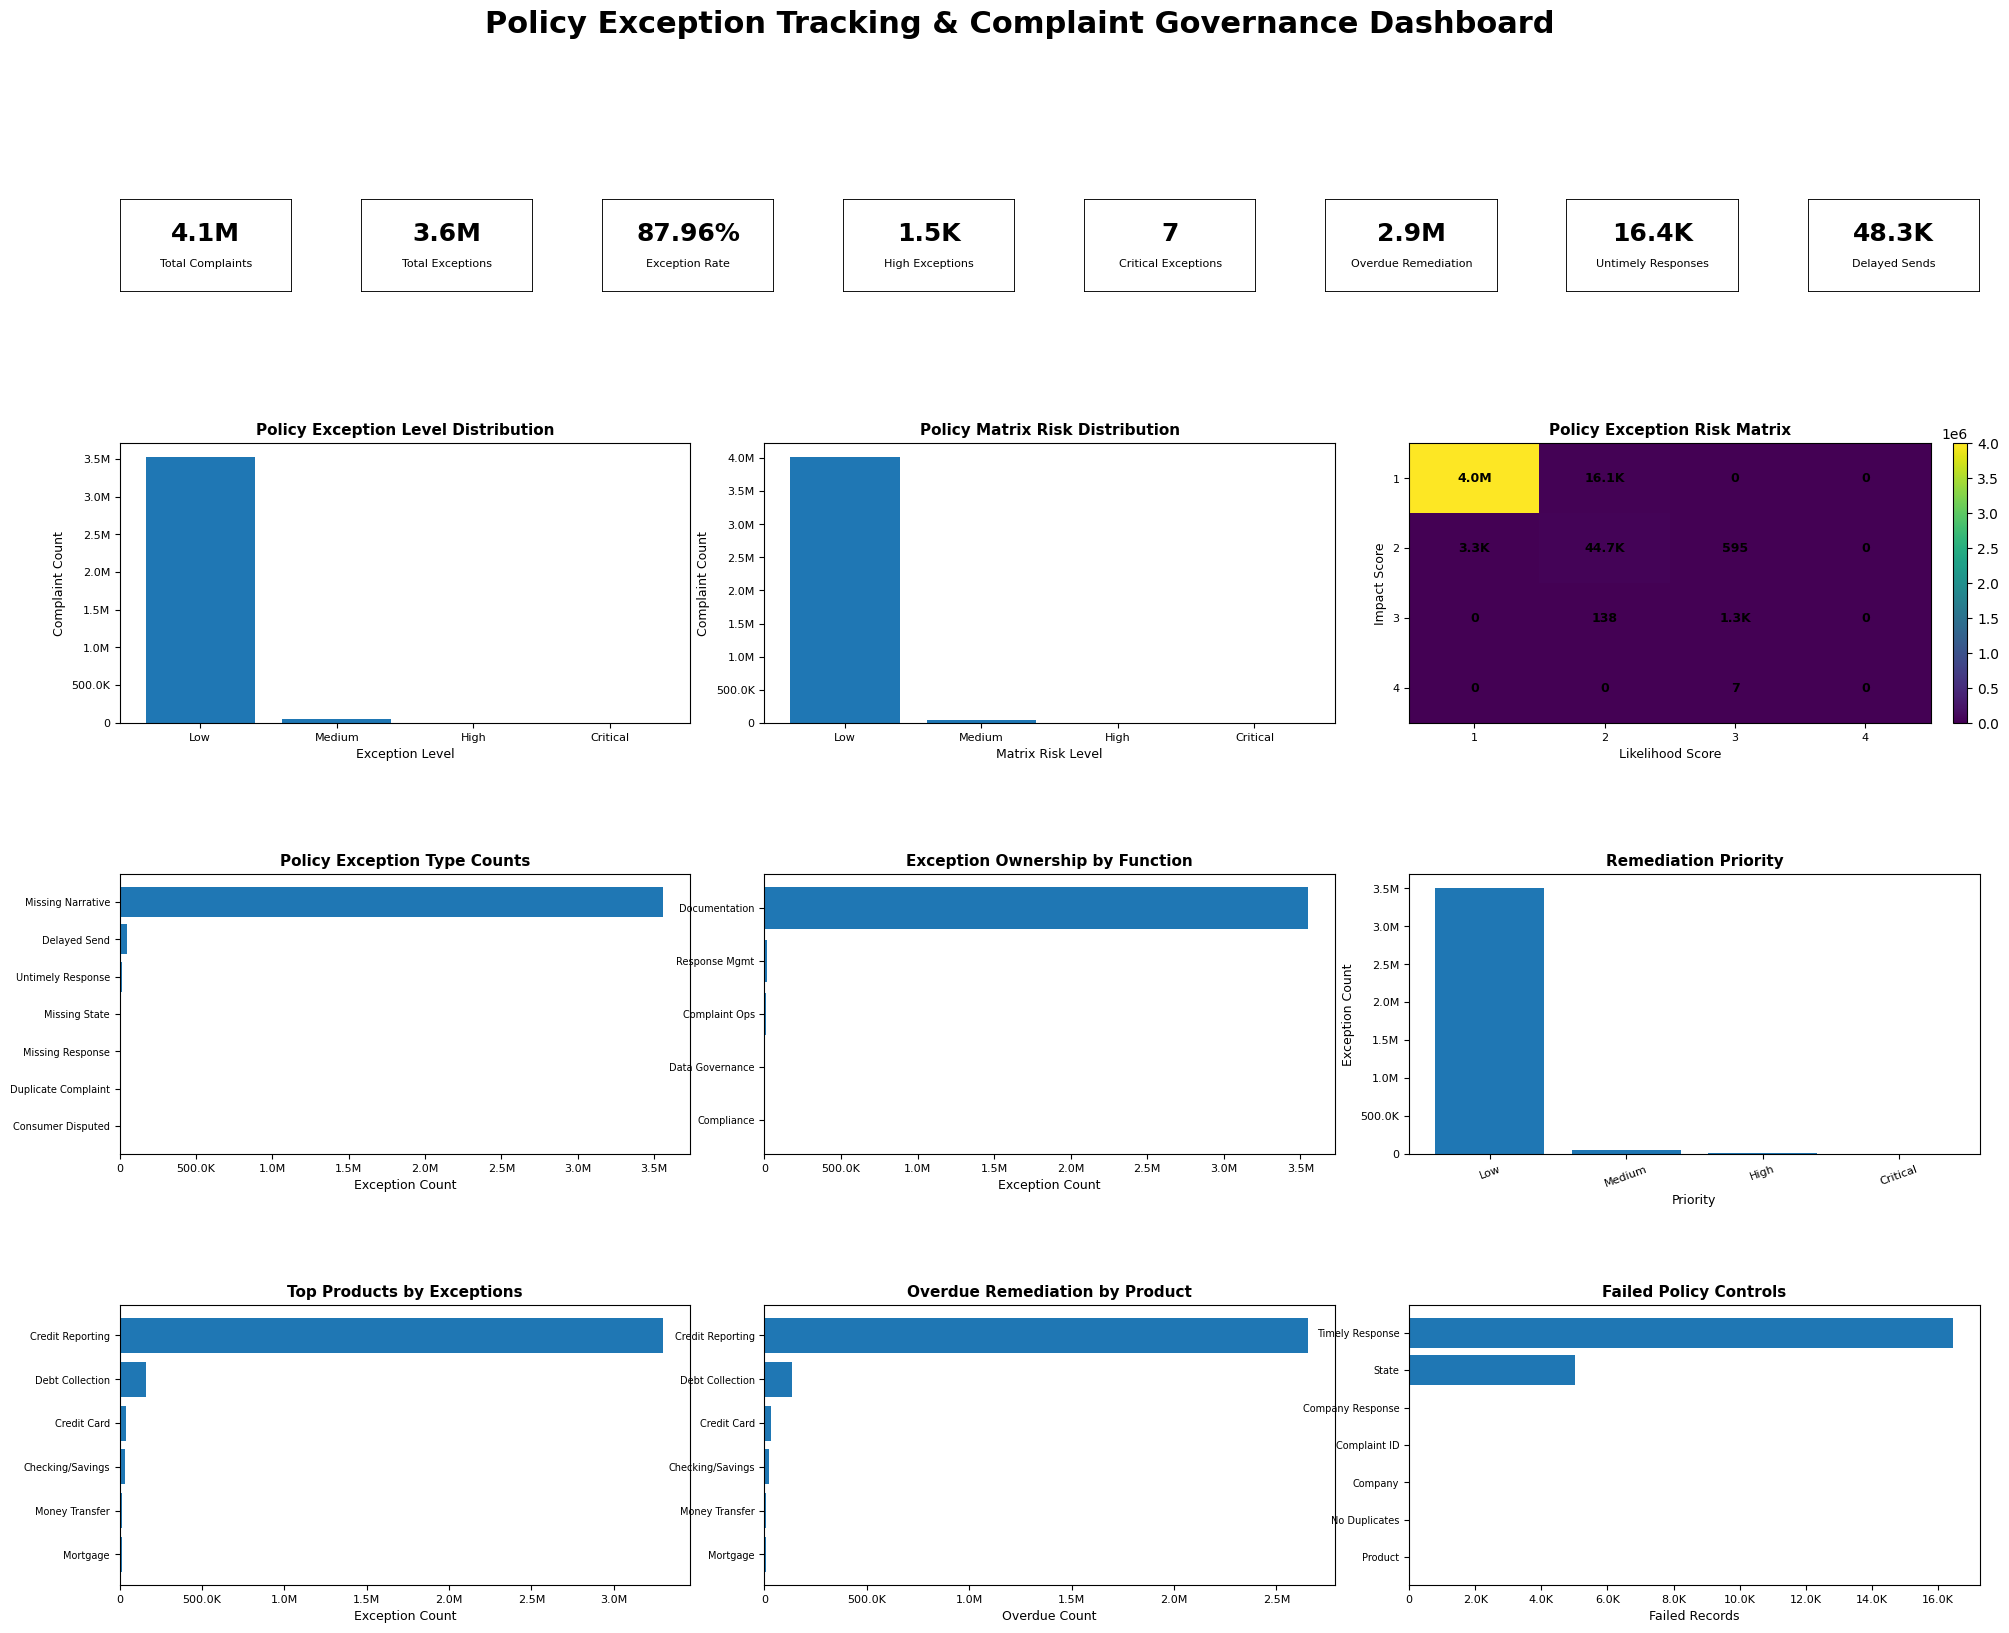

In [134]:
##======DASHBOARD======##

fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(
    nrows=4,
    ncols=12,
    height_ratios=[1.0, 3.0, 3.0, 3.0],
    hspace=0.65,
    wspace=0.85
)

fig.suptitle(
    "Policy Exception Tracking & Complaint Governance Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.985
)

# =========================
# KPI ROW
# =========================
kpi_gs = gs[0, :].subgridspec(1, 8, wspace=0.40)

kpi_values = [
    ("Total Complaints", format_number(total_complaints), None),
    ("Total Exceptions", format_number(total_exceptions), None),
    ("Exception Rate", f"{exception_rate}%", None),
    ("High Exceptions", format_number(high_exceptions), None),
    ("Critical Exceptions", format_number(critical_exceptions), None),
    ("Overdue Remediation", format_number(overdue_remediation), None),
    ("Untimely Responses", format_number(untimely_responses), None),
    ("Delayed Sends", format_number(delayed_sends), None)
]

for i, item in enumerate(kpi_values):
    ax = fig.add_subplot(kpi_gs[0, i])
    create_kpi_card(ax, item[0], item[1], item[2])

# formatter
fmt = FuncFormatter(axis_compact)

# =========================
# ROW 1
# =========================
ax1 = fig.add_subplot(gs[1, 0:4])
ax2 = fig.add_subplot(gs[1, 4:8])
ax3 = fig.add_subplot(gs[1, 8:12])

# Policy Exception Level Distribution
ax1.bar(exception_level_counts_no_none.index, exception_level_counts_no_none.values)
ax1.set_title("Policy Exception Level Distribution", fontsize=11, fontweight="bold")
ax1.set_xlabel("Exception Level", fontsize=9)
ax1.set_ylabel("Complaint Count", fontsize=9)
ax1.tick_params(labelsize=8)
ax1.yaxis.set_major_formatter(fmt)

# Policy Matrix Risk Distribution
ax2.bar(matrix_level_counts.index, matrix_level_counts.values)
ax2.set_title("Policy Matrix Risk Distribution", fontsize=11, fontweight="bold")
ax2.set_xlabel("Matrix Risk Level", fontsize=9)
ax2.set_ylabel("Complaint Count", fontsize=9)
ax2.tick_params(labelsize=8)
ax2.yaxis.set_major_formatter(fmt)

# Policy Risk Matrix
matrix_plot = ax3.imshow(policy_risk_matrix, aspect="auto")

for i in range(policy_risk_matrix.shape[0]):
    for j in range(policy_risk_matrix.shape[1]):
        value = int(policy_risk_matrix.iloc[i, j])
        ax3.text(
            j, i, format_number(value),
            ha="center", va="center",
            fontsize=9, fontweight="bold"
        )

ax3.set_xticks(range(4))
ax3.set_xticklabels(["1", "2", "3", "4"])
ax3.set_yticks(range(4))
ax3.set_yticklabels(["1", "2", "3", "4"])
ax3.set_xlabel("Likelihood Score", fontsize=9)
ax3.set_ylabel("Impact Score", fontsize=9)
ax3.set_title("Policy Exception Risk Matrix", fontsize=11, fontweight="bold")
ax3.tick_params(labelsize=8)

fig.colorbar(matrix_plot, ax=ax3, fraction=0.046, pad=0.04)

# =========================
# ROW 2
# =========================
ax4 = fig.add_subplot(gs[2, 0:4])
ax5 = fig.add_subplot(gs[2, 4:8])
ax6 = fig.add_subplot(gs[2, 8:12])

# Policy Exception Type Counts
ax4.barh(exception_type_labels, exception_type_counts.values)
ax4.set_title("Policy Exception Type Counts", fontsize=11, fontweight="bold")
ax4.set_xlabel("Exception Count", fontsize=9)
ax4.tick_params(axis="y", labelsize=7)
ax4.tick_params(axis="x", labelsize=8)
ax4.xaxis.set_major_formatter(fmt)

# Exception Ownership by Function
ax5.barh(owner_counts.index, owner_counts.values)
ax5.set_title("Exception Ownership by Function", fontsize=11, fontweight="bold")
ax5.set_xlabel("Exception Count", fontsize=9)
ax5.tick_params(axis="y", labelsize=7)
ax5.tick_params(axis="x", labelsize=8)
ax5.xaxis.set_major_formatter(fmt)

# Remediation Priority
ax6.bar(priority_counts.index, priority_counts.values)
ax6.set_title("Remediation Priority", fontsize=11, fontweight="bold")
ax6.set_xlabel("Priority", fontsize=9)
ax6.set_ylabel("Exception Count", fontsize=9)
ax6.tick_params(axis="x", rotation=20, labelsize=8)
ax6.tick_params(axis="y", labelsize=8)
ax6.yaxis.set_major_formatter(fmt)

# =========================
# ROW 3
# =========================
ax7 = fig.add_subplot(gs[3, 0:4])
ax8 = fig.add_subplot(gs[3, 4:8])
ax9 = fig.add_subplot(gs[3, 8:12])

# Top Products by Exceptions
ax7.barh(exceptions_by_product.index, exceptions_by_product.values)
ax7.set_title("Top Products by Exceptions", fontsize=11, fontweight="bold")
ax7.set_xlabel("Exception Count", fontsize=9)
ax7.tick_params(axis="y", labelsize=7)
ax7.tick_params(axis="x", labelsize=8)
ax7.xaxis.set_major_formatter(fmt)

# Overdue Remediation by Product
ax8.barh(overdue_by_product.index, overdue_by_product.values)
ax8.set_title("Overdue Remediation by Product", fontsize=11, fontweight="bold")
ax8.set_xlabel("Overdue Count", fontsize=9)
ax8.tick_params(axis="y", labelsize=7)
ax8.tick_params(axis="x", labelsize=8)
ax8.xaxis.set_major_formatter(fmt)

# Failed Policy Controls
ax9.barh(failed_control_chart["short_control"], failed_control_chart["Failed"])
ax9.set_title("Failed Policy Controls", fontsize=11, fontweight="bold")
ax9.set_xlabel("Failed Records", fontsize=9)
ax9.tick_params(axis="y", labelsize=7)
ax9.tick_params(axis="x", labelsize=8)
ax9.xaxis.set_major_formatter(fmt)

plt.savefig(
    "outputs/charts/policy_exception_governance_dashboard_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Executive Policy Exception Dashboard

The Policy Exception Tracking & Complaint Governance Dashboard provides an executive-level view of complaint-related policy exceptions, remediation exposure, governance risk, and control effectiveness.

The dashboard consolidates key policy exception indicators, including total complaints, total exceptions, exception rate, high and critical exceptions, overdue remediation items, untimely responses, and delayed company routing.

The policy exception level distribution summarizes exception severity across complaints. The policy risk matrix evaluates complaint governance exposure using an impact and likelihood framework, allowing high-risk exception concentrations to be prioritized for review.

The exception type chart identifies the most common exception categories, including untimely responses, missing company responses, disputed complaints, missing documentation, missing state information, delayed complaint routing, and duplicate complaint records.

The ownership and remediation priority views simulate an enterprise issue management workflow by showing which governance functions are responsible for exception review and which items require higher-priority remediation.

The product-level exception and overdue remediation charts identify complaint product categories with the greatest governance exposure.

The failed controls chart summarizes policy governance control failures related to complaint completeness, response documentation, timely response performance, state completeness, and duplicate complaint prevention.

Overall, this dashboard supports policy exception monitoring, complaint governance, operational risk oversight, remediation tracking, audit readiness, and executive decision-making.

---